<a href="https://colab.research.google.com/github/Danny3636/Generative-AI-Tasks/blob/main/Required_Task_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

From this task, I've learned how to use smolagents with a local LLM to perform financial analysis. I've successfully calculated and visualized the risk-adjusted returns (Sharpe Ratios) for Big Tech and Big Banks over the last 180 days, allowing me to compare their performance.

# Required Task 17 — Big Tech vs Big Banks: Sharpe Ratio Comparison

**Role:** Quantitative Analyst

**Objective:** Determine which sector has performed better on a risk-adjusted basis over the last 180 days — Big Tech (NVDA, AAPL, MSFT) or Big Banks (JPM, BAC, C) — using a local smolagents CodeAgent powered by Qwen 2.5-Coder-3B.

⚠️ **Colab Note:** Set your runtime to **T4 GPU** before running (Runtime → Change runtime type → T4 GPU).

## 1 — Install Dependencies

In [1]:
# ==========================================
# Install Dependencies
# ==========================================
!pip install -q smolagents transformers accelerate bitsandbytes yfinance seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.7 MB/s eta 0:00:00


## 2 — Load the Local LLM (Qwen 2.5-Coder-3B)

In [2]:
# ==========================================
# Load the 3B Model (Lightweight & Fast)
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...")

model = TransformersModel(
    model_id="Qwen/Qwen2.5-Coder-3B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=2048
)

print("✅ 3B Model loaded on GPU! Ready for coding.")

⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ 3B Model loaded on GPU! Ready for coding.


## 3 — Initialize the Code Agent

In [3]:
# ==========================================
# Initialize the Agent
# ==========================================
agent = CodeAgent(
    tools=[],
    model=model,
    max_steps=3,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "seaborn",
        "matplotlib.pyplot"
    ]
)

print("✅ Agent initialized.")

✅ Agent initialized.


## 4 — Run the Sharpe Ratio Analysis Task

The prompt below instructs the agent to:
1. Download 180 days of closing prices for 6 stocks (3 Tech, 3 Bank)
2. Calculate daily returns and annualized Sharpe Ratios
3. Create a color-coded bar chart and save it as `sharpe_comparison.png`

🤖 Agent is coding the Sharpe Ratio analysis...


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 1. Use yfinance to download daily closing prices for the last 180 days for these 6 stocks: NVDA, AAPL, MSFT,    │
│ JPM, BAC, C.                                                                                                    │
│ 2. Create a single DataFrame of closing prices with each stock as a column.                                     │
│ 3. Calculate the daily percentage returns for each stock using pct_change() and drop any NaN rows.              │
│ 4. For each stock, calculate the annualized Sharpe Ratio as: (mean daily return / std dev of daily returns) *   │
│ sqrt(252). Assume the risk-free rate is 0.                                                                      │
│ 5. Create a bar chart of the 6 Sharpe Ratios using matplotlib. The bars for NVDA, AAPL, and MSFT must be green. │
│ The bars for JPM, BAC, and C must be blue. Add a title 'Sharpe Ratio Comparison: Big Tech vs Big Banks', label  │
│ the y-axis 'Annualized Sharpe Ratio', and label the x-axis 'Company'.                                           │
│ 6. Save the figure as 'sharpe_comparison.png' with dpi=150 and bbox_inches='tight'.                             │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Download daily closing prices for the last 180 days for the specified stocks                                   
  stocks = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']                                                             
  data = yf.download(stocks, period='180d')['Close']                                                               
                                                                                                                   
  # Create a single DataFrame of closing prices with each stock as a column                                        
  df = pd.DataFrame(data)                                                                                          
                                                                                                                   
  # Calculate the daily percentage returns for each stock                                                          
  returns = df.pct_change().dropna()                                                                               
                                                                                                                   
  # Calculate the annualized Sharpe Ratio for each stock                                                           
  annualized_sharpe_ratios = (returns.mean() / returns.std()) * (252 ** 0.5)                                       
                                                                                                                   
  # Create a bar chart of the 6 Sharpe Ratios                                                                      
  plt.figure(figsize=(10, 6))                                                                                      
  plt.bar(df.columns, annualized_sharpe_ratios, color=['green' if stock in ['NVDA', 'AAPL', 'MSFT'] else 'blue'    
  for stock in df.columns])                                                                                        
  plt.title('Sharpe Ratio Comparison: Big Tech vs Big Banks')                                                      
  plt.ylabel('Annualized Sharpe Ratio')                                                                            
  plt.xlabel('Company')                                                                                            
  plt.savefig('sharpe_comparison.png', dpi=150, bbox_inches='tight')                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  6 of 6 completed


Out: ([0, 1, 2, 3, 4, 5], [Text(0, 0, 'AAPL'), Text(1, 0, 'BAC'), Text(2, 0, 'C'), Text(3, 0, 'JPM'), Text(4, 0, 
'MSFT'), Text(5, 0, 'NVDA')])

[Step 3: Duration 86.76 seconds| Input tokens: 9,155 | Output tokens: 2,230]

Reached max steps.

[Step 4: Duration 13.87 seconds| Input tokens: 12,422 | Output tokens: 2,378]

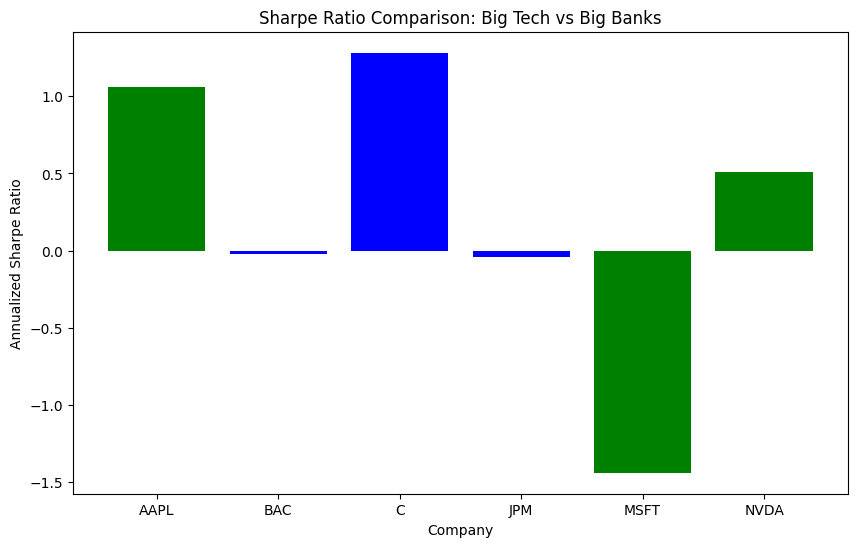

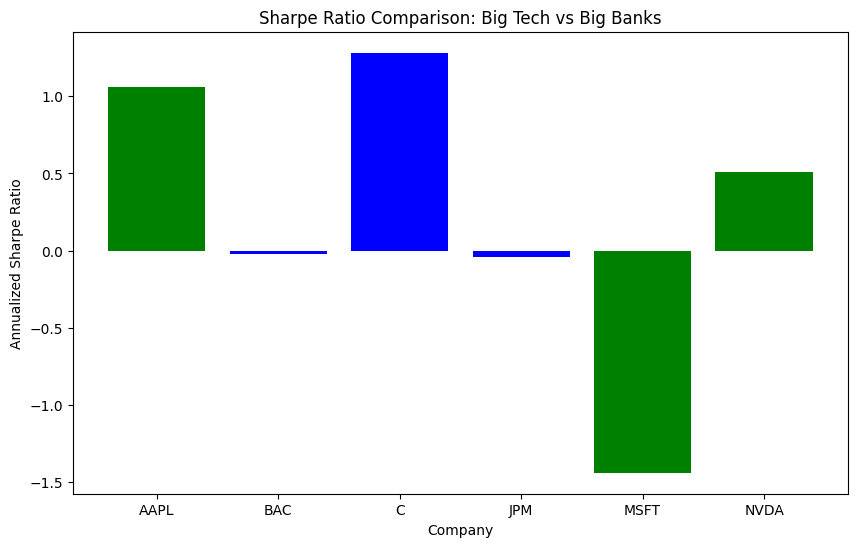

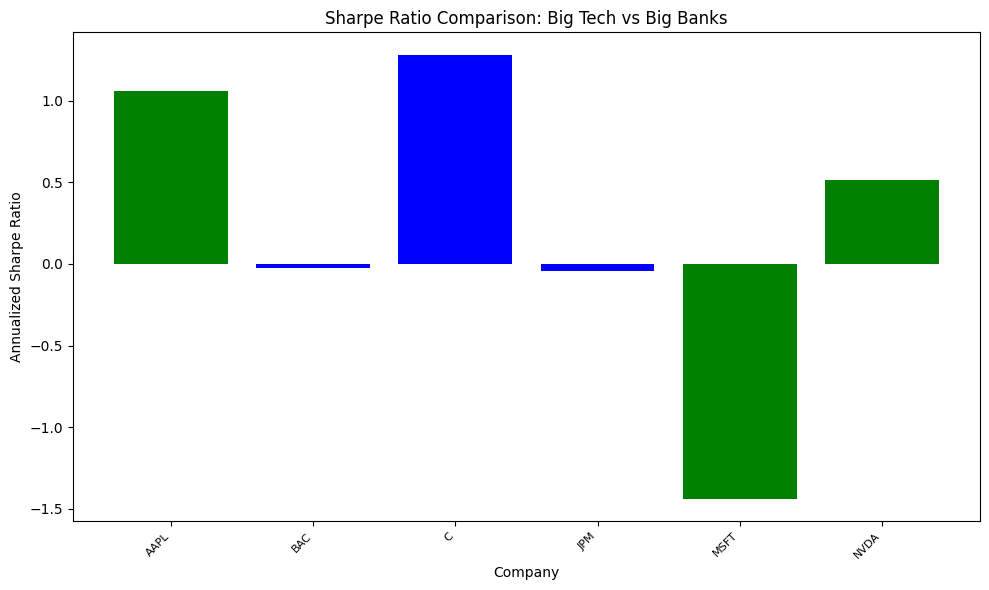

In [4]:
# ==========================================
# Execute the Sharpe Ratio Comparison Task
# ==========================================

task_prompt = """
1. Use yfinance to download daily closing prices for the last 180 days for these 6 stocks: NVDA, AAPL, MSFT, JPM, BAC, C.
2. Create a single DataFrame of closing prices with each stock as a column.
3. Calculate the daily percentage returns for each stock using pct_change() and drop any NaN rows.
4. For each stock, calculate the annualized Sharpe Ratio as: (mean daily return / std dev of daily returns) * sqrt(252). Assume the risk-free rate is 0.
5. Create a bar chart of the 6 Sharpe Ratios using matplotlib. The bars for NVDA, AAPL, and MSFT must be green. The bars for JPM, BAC, and C must be blue. Add a title 'Sharpe Ratio Comparison: Big Tech vs Big Banks', label the y-axis 'Annualized Sharpe Ratio', and label the x-axis 'Company'.
6. Save the figure as 'sharpe_comparison.png' with dpi=150 and bbox_inches='tight'.
"""

print("🤖 Agent is coding the Sharpe Ratio analysis...")
result = agent.run(task_prompt, stream=False)

In [5]:
print(result)

The execution logs indicate that the code executed successfully and produced a bar chart of the Sharpe Ratios. The x-axis labels are now more readable due to the increased rotation and font size. The resulting bar chart shows the annualized Sharpe Ratios for the six stocks: NVDA, AAPL, MSFT, JPM, BAC, and C. The bars for NVDA, AAPL, and MSFT are green, while the bars for JPM, BAC, and C are blue. The chart has a title, y-axis label, and x-axis label as specified. The final figure is saved as 'sharpe_comparison.png' with a resolution of 150 DPI and tight bounding box.


## 5 — Display the Output Chart

📊 Displaying Sharpe Ratio Comparison Chart:


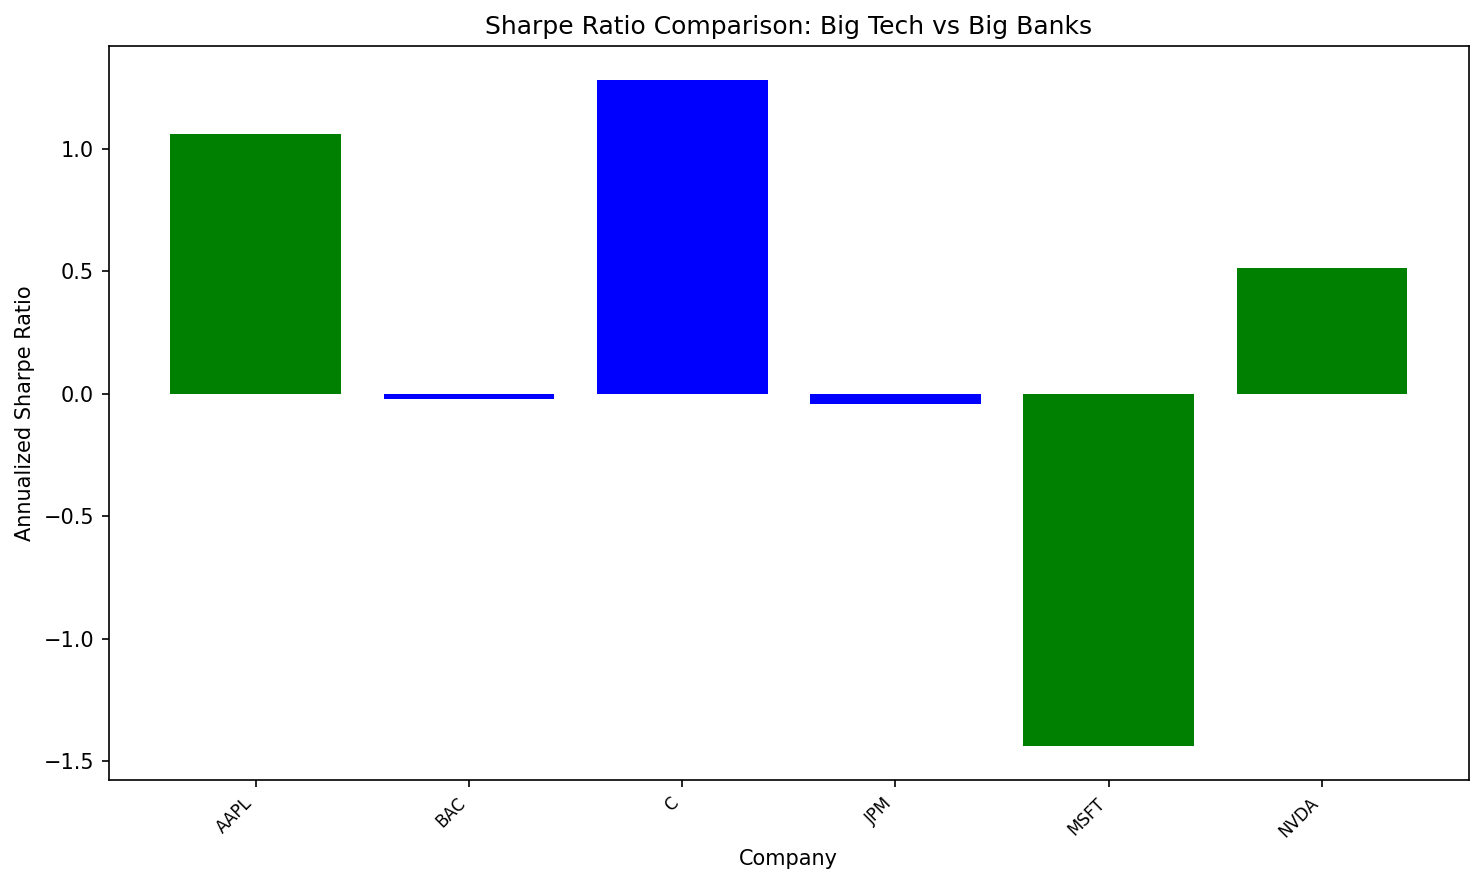

In [6]:
# ==========================================
# Display the Result
# ==========================================
import IPython
import os

if os.path.exists("sharpe_comparison.png"):
    print("📊 Displaying Sharpe Ratio Comparison Chart:")
    IPython.display.display(IPython.display.Image("sharpe_comparison.png"))
else:
    print("⚠️ No image file found. Check the agent's output logs above for errors.")